## 참고 자료   
---
reference : [8) BiLSTM으로 한국어 스팀 리뷰 감성 분류하기](https://wikidocs.net/94748)   
참고 : [Google-Colab에서-Mecab-koMecab-ko-dic-쉽게-사용하기](https://somjang.tistory.com/entry/Google-Colab%EC%97%90%EC%84%9C-Mecab-koMecab-ko-dic-%EC%89%BD%EA%B2%8C-%EC%82%AC%EC%9A%A9%ED%95%98%EA%B8%B0)   
참고 2 : [구글 코랩(Google Colab)에서 Mecab 형태소 분석기, konlpy 쉽게 설치하기](https://teddylee777.github.io/colab/colab-mecab)   
참고 3 : [Google Colaboratory 사용법](https://velog.io/@s6820w/colab1)

---
## Colab에 Mecab 설치
---

In [45]:
# 어텐션 라이브러리 설치
!pip install attention

# Colab에 Mecab 설치
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab
!bash install_mecab-ko_on_colab190912.sh

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Cloning into 'Mecab-ko-for-Google-Colab'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 115 (delta 11), reused 10 (delta 3), pack-reused 91
Receiving objects: 100% (115/115), 1.27 MiB | 9.50 MiB/s, done.
Resolving deltas: 100% (50/50), done.
/content/Mecab-ko-for-Google-Colab/Mecab-ko-for-Google-Colab
Installing konlpy.....
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2022-07-25 12:41:19--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 104.192.141.1, 2406:da00:ff00::3403:4be7, 2406:da00:ff00::6b17:d1f5, ...
Connecting to bitbucke

---
## 파일 경로 확인
---

In [46]:
import os

for dirname, _, filenames in os.walk('/content/drive/MyDrive/Colab Notebooks/data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/content/drive/MyDrive/Colab Notebooks/data/processed_gameWReview_02.csv
/content/drive/MyDrive/Colab Notebooks/data/topSellerGameID.csv
/content/drive/MyDrive/Colab Notebooks/data/topSellerGames.csv
/content/drive/MyDrive/Colab Notebooks/data/topSellGameWReview.csv
/content/drive/MyDrive/Colab Notebooks/data/gameID.csv
/content/drive/MyDrive/Colab Notebooks/data/gameIDver02.csv
/content/drive/MyDrive/Colab Notebooks/data/games.csv
/content/drive/MyDrive/Colab Notebooks/data/games_02.csv
/content/drive/MyDrive/Colab Notebooks/data/gameWReview.csv
/content/drive/MyDrive/Colab Notebooks/data/gameWReview_02.csv
/content/drive/MyDrive/Colab Notebooks/data/steam_game_prediction.csv
/content/drive/MyDrive/Colab Notebooks/data/processed_gameWReview.csv
/content/drive/MyDrive/Colab Notebooks/data/steam_trainset.txt
/content/drive/MyDrive/Colab Notebooks/data/totalSellersWReview.csv


In [47]:
gameIDver02_path = "/content/drive/MyDrive/Colab Notebooks/data/gameIDver02.csv"
games_02_path = "/content/drive/MyDrive/Colab Notebooks/data/games_02.csv"
gameWReview_02_path = "/content/drive/MyDrive/Colab Notebooks/data/gameWReview_02.csv"
gameID_path = "/content/drive/MyDrive/Colab Notebooks/data/gameID.csv"
games_path = "/content/drive/MyDrive/Colab Notebooks/data/games.csv"
gameWReview_path = "/content/drive/MyDrive/Colab Notebooks/data/gameWReview.csv"
processed_gameWReview_path = "/content/drive/MyDrive/Colab Notebooks/data/processed_gameWReview.csv"
steam_game_prediction_path = "/content/drive/MyDrive/Colab Notebooks/data/steam_game_prediction.csv"
steam_trainset_path = "/content/drive/MyDrive/Colab Notebooks/data/steam_trainset.txt"
totalSellersWReview_path = "/content/drive/MyDrive/Colab Notebooks/data/totalSellersWReview.csv"

---
## 시드 설정, 파일 불러오기   
---
간단한 결측치 처리는 덤

In [48]:
import numpy as np
import tensorflow as tf

seed = 220711
np.random.seed(seed)
tf.random.set_seed(seed)

print("Tensorflow Version",tf.__version__)

Tensorflow Version 2.8.2


In [49]:
import pandas as pd

sample_data = pd.read_table(steam_trainset_path, names=['label', 'reviews'])
pred_data = pd.read_csv(totalSellersWReview_path)
print(sample_data.info(), end="\n\n")
pred_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   label    100000 non-null  int64 
 1   reviews  100000 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.5+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3015 entries, 0 to 3014
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          3015 non-null   int64  
 1   appid               3015 non-null   float64
 2   title               3015 non-null   object 
 3   releaseDate         2942 non-null   object 
 4   price               2866 non-null   float64
 5   developer tier      3015 non-null   float64
 6   publisher tier      3015 non-null   float64
 7   genre               3008 non-null   object 
 8   early access        3015 non-null   float64
 9   achievement         3015 non-nul

In [50]:
pred_data = pred_data.dropna(subset=['releaseDate', 'price', 'positive review', 'negative review', 'review'])  # 필수로 있어야 하는 속성 기준으로 결측 샘플 삭제
pred_data["releaseDate"] = pd.to_datetime(pred_data["releaseDate"])  # 날짜 형변환
pred_data["releaseYear"] = pd.DatetimeIndex(pred_data["releaseDate"]).year 
pred_data.drop_duplicates(subset=['review'], inplace=True) # reviews 열에서 중복인 내용이 있다면 중복 제거
pred_data.to_csv("/content/drive/MyDrive/Colab Notebooks/data/processed_gameWReview_02.csv")
pred_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1335 entries, 0 to 3014
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Unnamed: 0          1335 non-null   int64         
 1   appid               1335 non-null   float64       
 2   title               1335 non-null   object        
 3   releaseDate         1335 non-null   datetime64[ns]
 4   price               1335 non-null   float64       
 5   developer tier      1335 non-null   float64       
 6   publisher tier      1335 non-null   float64       
 7   genre               1332 non-null   object        
 8   early access        1335 non-null   float64       
 9   achievement         1335 non-null   float64       
 10  tag                 1335 non-null   object        
 11  languages           1335 non-null   float64       
 12  steam award         1335 non-null   float64       
 13  DLC                 1335 non-null   float64     

In [51]:
print(pred_data["releaseDate"].min())  # 날짜 오브젝트 속성 중 최솟값 출력
print(pred_data["releaseDate"].max())  # 날짜 오브젝트 속성 중 최댓값 출력

1985-06-01 00:00:00
2022-07-20 00:00:00


### 프로젝트용 데이터에서 리뷰 데이터만 분리

In [52]:
pred_data = pred_data[["appid", "review"]]
pred_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1335 entries, 0 to 3014
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   appid   1335 non-null   float64
 1   review  1335 non-null   object 
dtypes: float64(1), object(1)
memory usage: 31.3+ KB


### 결측값 처리

In [53]:
pred_data['review'] = pred_data['review'].fillna("내용없음")
pred_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1335 entries, 0 to 3014
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   appid   1335 non-null   float64
 1   review  1335 non-null   object 
dtypes: float64(1), object(1)
memory usage: 31.3+ KB


---
## 리뷰 데이터 전처리
---

In [54]:
# 중복 확인
sample_data['reviews'].nunique(), sample_data['label'].nunique()

(99892, 2)

In [55]:
# 중복 제거
sample_data.drop_duplicates(subset=['reviews'], inplace=True) # reviews 열에서 중복인 내용이 있다면 중복 제거
print('학습셋 총 샘플의 수 :',len(sample_data))
print()
print(sample_data.info())

학습셋 총 샘플의 수 : 99892

<class 'pandas.core.frame.DataFrame'>
Int64Index: 99892 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    99892 non-null  int64 
 1   reviews  99892 non-null  object
dtypes: int64(1), object(1)
memory usage: 2.3+ MB
None


In [56]:
# 결측값 확인
print(sample_data.isnull().values.any())

False


### 텍스트 정리   
정규식으로 한글만 남기고 다 지움   
처리 후 결측값 확인

In [57]:
sample_data['reviews'] = sample_data['reviews'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","")
sample_data['reviews'].replace('', "내용없음", inplace=True)
print(sample_data.isnull().sum(), end="\n\n")

pred_data['review'] = pred_data['review'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","")  # 정규 표현식 수행
pred_data['review'].replace('', "내용없음", inplace=True)
print(pred_data.isnull().sum(), end="\n\n")

total = pd.DataFrame({"review": pd.concat([sample_data['reviews'], pred_data['review']], ignore_index=True)})
total.info()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  """Entry point for launching an IPython kernel.


label      0
reviews    0
dtype: int64

appid     0
review    0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101227 entries, 0 to 101226
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   review  101227 non-null  object
dtypes: object(1)
memory usage: 791.0+ KB


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:5: FutureWarning: The default value of regex will change from True to False in a future version.
  """


In [58]:
# 불용어 정의
stopwords = ['도', '는', '다', '의', '가', '이', '은', '한', '에', '하', '고', '을', '를', '인', '듯', '과', '와', '네', '들', '듯', '지', '임', '게', '만', '게임', '겜', '되', '음', '면']
print(stopwords)

['도', '는', '다', '의', '가', '이', '은', '한', '에', '하', '고', '을', '를', '인', '듯', '과', '와', '네', '들', '듯', '지', '임', '게', '만', '게임', '겜', '되', '음', '면']


### Mecab 형태소분석기

In [59]:
from konlpy.tag import Mecab

mecab = Mecab()

sample_data['tokenized'] = sample_data['reviews'].apply(mecab.morphs)
sample_data['tokenized'] = sample_data['tokenized'].apply(lambda x: [item for item in x if item not in stopwords])

pred_data['tokenized'] = pred_data['review'].apply(mecab.morphs)
pred_data['tokenized'] = pred_data['tokenized'].apply(lambda x: [item for item in x if item not in stopwords])

total_token_review = pd.DataFrame({"tokenized reviews": pd.concat([sample_data['tokenized'], pred_data['tokenized']], ignore_index=True)})
total_token_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101227 entries, 0 to 101226
Data columns (total 1 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   tokenized reviews  101227 non-null  object
dtypes: object(1)
memory usage: 791.0+ KB


In [60]:
print(total_token_review["tokenized reviews"][99892])

['플레이', '시간', '증명', '해', '줌']


### 학습셋 테스트셋 분리

In [61]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(sample_data, test_size = 0.25, random_state = 42)
print('훈련용 리뷰의 개수 :', len(train_data))
print('테스트용 리뷰의 개수 :', len(test_data))

훈련용 리뷰의 개수 : 74919
테스트용 리뷰의 개수 : 24973


In [62]:
X_train = train_data['tokenized'].values
y_train = train_data['label'].values

X_test= test_data['tokenized'].values
y_test = test_data['label'].values

x_pred = pred_data['tokenized'].values
y_pred = pred_data['appid'].values

x_total = total_token_review["tokenized reviews"]

### 토크나이저 생성 및 `fit_on_texts`

In [63]:
# tf.keras.preprocessing.text.Tokenizer
# tf.keras.preprocessing.sequence.pad_sequences

tokenizer = tf.keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts(x_total)

### 단어 집합 정보 확인

In [64]:
threshold = 2
total_cnt = len(tokenizer.word_index)  # 단어의 수
rare_cnt = 0  # 등장 빈도수가 threshold보다 작은 단어의 개수를 카운트
total_freq = 0  # 훈련 데이터의 전체 단어 빈도수 총 합
rare_freq = 0  # 등장 빈도수가 threshold보다 작은 단어의 등장 빈도수의 총 합

# 단어와 빈도수의 쌍(pair)을 key와 value로 받는다.
for key, value in tokenizer.word_counts.items():
    total_freq = total_freq + value

    # 단어의 등장 빈도수가 threshold보다 작으면
    if(value < threshold):
        rare_cnt = rare_cnt + 1
        rare_freq = rare_freq + value

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print(f'등장 빈도가 {threshold - 1}번 이하인 희귀 단어의 수: {rare_cnt}')
print(f"단어 집합에서 희귀 단어의 비율: {(rare_cnt / total_cnt) * 100 :.3f}")
print(f"전체 등장 빈도에서 희귀 단어 등장 빈도 비율: {(rare_freq / total_freq) * 100 :.3f}")

단어 집합(vocabulary)의 크기 : 38776
등장 빈도가 1번 이하인 희귀 단어의 수: 15903
단어 집합에서 희귀 단어의 비율: 41.012
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 0.966


In [65]:
# 전체 단어 개수 중 빈도수 2이하인 단어 개수는 제거.
# 0번 패딩 토큰과 1번 OOV 토큰을 고려하여 +2

vocab_size = total_cnt - rare_cnt + 2
print('단어 집합의 크기 :',vocab_size)

단어 집합의 크기 : 22875


### `texts_to_sequences`

In [66]:
# 'OOV' : Out of Vocabulary
tokenizer = tf.keras.preprocessing.text.Tokenizer(vocab_size, oov_token = 'OOV')
tokenizer.fit_on_texts(x_total)
x_total_tts = tokenizer.texts_to_sequences(x_total)
X_train_tts = tokenizer.texts_to_sequences(X_train)
X_test_tts = tokenizer.texts_to_sequences(X_test)
x_pred_tts = tokenizer.texts_to_sequences(x_pred)

print(x_pred[0])
print(x_pred_tts[0])

['플레이', '시간', '증명', '해', '줌']
[28, 33, 4288, 10, 1218]


### 데이터 통계 정보 확인
참고 : [\[Numpy\] 4. 통계량 구하기](https://zephyrus1111.tistory.com/149)

예측셋 리뷰의 최대 길이 : 2147
예측셋 리뷰의 평균 길이 : 102.514
예측셋 리뷰 길이 중간값 : 25
예측셋 리뷰 길이 상위 90% : 297.0


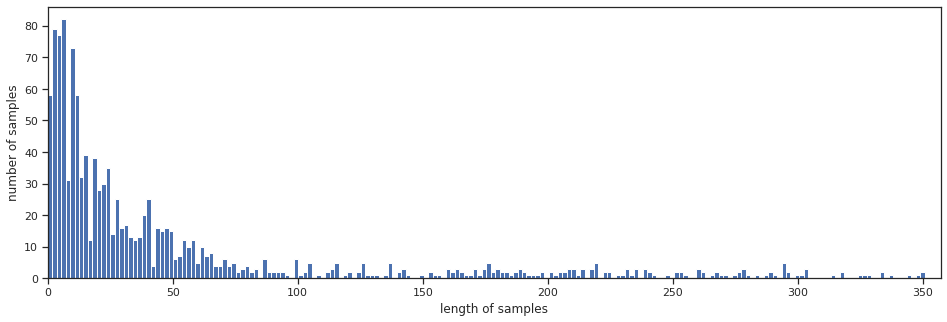


전체 리뷰의 최대 길이 : 2147
전체 리뷰의 평균 길이 : 16.263
전체 리뷰 길이 중간값 : 12
전체 리뷰 길이 상위 90% : 34.0


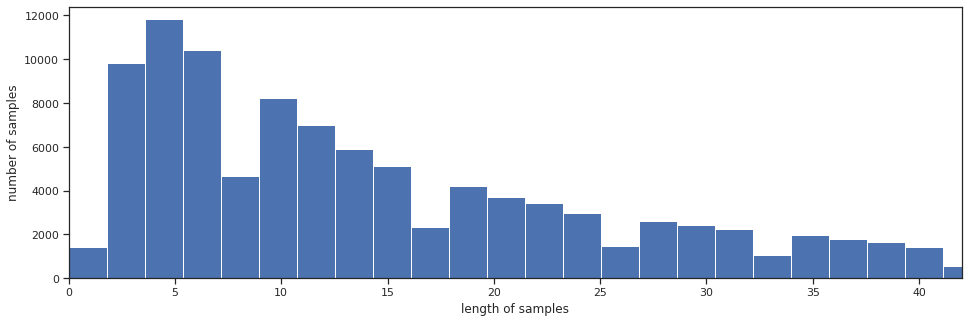

In [67]:
import matplotlib.pyplot as plt

def define_max_len(data):
    review_len = np.array([len(review) for review in data])
    max_len = int(np.quantile(review_len, 0.90)) + 1
    return max_len

def review_statistics(data, set_name):
    review_len = np.array([len(review) for review in data])

    max_len = int(np.quantile(review_len, 0.90)) + 1
    median_len = int(np.median(review_len))

    print(f'{set_name} 리뷰의 최대 길이 : {review_len.max()}')
    print(f'{set_name} 리뷰의 평균 길이 : {review_len.mean() :.3f}')
    print(f'{set_name} 리뷰 길이 중간값 : {median_len}')
    print(f'{set_name} 리뷰 길이 상위 90% : {np.quantile(review_len, 0.90)}')

    plt.hist(review_len, bins=1200)
    plt.xlabel('length of samples')
    plt.ylabel('number of samples')
    plt.xlim(0, int(max_len * 1.2))
    plt.show()
    return


review_statistics(x_pred_tts, "예측셋")
print()
review_statistics(x_total_tts, "전체")

In [68]:
def below_threshold_len(max_len, nested_list, set_name):
    count = 0
    for sentence in nested_list:
        if(len(sentence) <= max_len):
            count = count + 1
    print(f'{set_name} 샘플 중 길이가 {max_len} 이하인 샘플의 비율 : {(count / len(nested_list)) * 100 :.3f}')


below_threshold_len(define_max_len(x_total_tts), x_total_tts, "전체")
below_threshold_len(define_max_len(x_pred_tts), x_pred_tts, "예측셋")

max_len = define_max_len(x_pred_tts)
review_len = np.array([len(review) for review in x_pred_tts])
median_len = int(np.median(review_len))

전체 샘플 중 길이가 35 이하인 샘플의 비율 : 91.786
예측셋 샘플 중 길이가 298 이하인 샘플의 비율 : 90.037


### 패딩

In [69]:
x_tt = tf.keras.preprocessing.sequence.pad_sequences(x_total_tts, maxlen=max_len, padding='post')
X_tr = tf.keras.preprocessing.sequence.pad_sequences(X_train_tts, maxlen=max_len, padding='post')
X_te = tf.keras.preprocessing.sequence.pad_sequences(X_test_tts, maxlen=max_len, padding='post')
x_pr = tf.keras.preprocessing.sequence.pad_sequences(x_pred_tts, maxlen=max_len, padding='post')

print(x_tt[99892])

[  28   33 4288   10 1218    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

In [70]:
print(x_pr[0])

[  28   33 4288   10 1218    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

---
## 모델 및 콜백 생성
---

### LSTM 모델

In [71]:
from tensorflow import keras
from keras.callbacks import EarlyStopping, ModelCheckpoint

MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/model/'
if not os.path.exists(MODEL_DIR):
    os.mkdir(MODEL_DIR)

modelpath="/content/drive/MyDrive/Colab Notebooks/model/steam_review_best_model_LSTM.h5f5"

epoch = 30
batch = 100

checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_accuracy', verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=max(int(epoch * 0.1), 3))

In [72]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Embedding, LSTM
from keras.layers import Dropout
from keras.layers import Conv1D, MaxPooling1D
from attention import Attention

model = Sequential([
    Embedding(vocab_size, input_length=max_len, output_dim=int(max_len * 0.5)),
    Conv1D(64, 4, padding='same', activation='relu', strides=1),
    MaxPooling1D(pool_size=2),
    Dropout(0.5),
    Conv1D(128, 3, padding='same', activation='relu', strides=1),
    MaxPooling1D(pool_size=2),
    Dropout(0.5),
    Conv1D(256, 2, padding='same', activation='relu', strides=1),
    MaxPooling1D(pool_size=2),
    Dropout(0.5),
    LSTM(128, return_sequences=True),
    Attention(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [73]:
history = model.fit(X_tr, y_train, validation_split=0.2, epochs=epoch, batch_size=batch, verbose=1, callbacks=[checkpointer, early_stopping_callback])

Epoch 1/30
600/600 [==============================] - ETA: 0s - loss: 0.5345 - accuracy: 0.7221
Epoch 1: val_accuracy improved from -inf to 0.78590, saving model to /content/drive/MyDrive/Colab Notebooks/model/steam_review_best_model_LSTM.h5f5


INFO:tensorflow:Assets written to: /content/drive/MyDrive/Colab Notebooks/model/steam_review_best_model_LSTM.h5f5/assets


INFO:tensorflow:Assets written to: /content/drive/MyDrive/Colab Notebooks/model/steam_review_best_model_LSTM.h5f5/assets


600/600 [==============================] - 343s 567ms/step - loss: 0.5345 - accuracy: 0.7221 - val_loss: 0.4581 - val_accuracy: 0.7859
Epoch 2/30
600/600 [==============================] - ETA: 0s - loss: 0.4048 - accuracy: 0.8208
Epoch 2: val_accuracy improved from 0.78590 to 0.78971, saving model to /content/drive/MyDrive/Colab Notebooks/model/steam_review_best_model_LSTM.h5f5


INFO:tensorflow:Assets written to: /content/drive/MyDrive/Colab Notebooks/model/steam_review_best_model_LSTM.h5f5/assets


INFO:tensorflow:Assets written to: /content/drive/MyDrive/Colab Notebooks/model/steam_review_best_model_LSTM.h5f5/assets


600/600 [==============================] - 336s 560ms/step - loss: 0.4048 - accuracy: 0.8208 - val_loss: 0.4620 - val_accuracy: 0.7897
Epoch 3/30
600/600 [==============================] - ETA: 0s - loss: 0.3296 - accuracy: 0.8618
Epoch 3: val_accuracy did not improve from 0.78971
600/600 [==============================] - 331s 551ms/step - loss: 0.3296 - accuracy: 0.8618 - val_loss: 0.4981 - val_accuracy: 0.7854
Epoch 4/30
600/600 [==============================] - ETA: 0s - loss: 0.2678 - accuracy: 0.8926
Epoch 4: val_accuracy did not improve from 0.78971
600/600 [==============================] - 334s 557ms/step - loss: 0.2678 - accuracy: 0.8926 - val_loss: 0.5228 - val_accuracy: 0.7814


In [74]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 298, 149)          3408375   
                                                                 
 conv1d_9 (Conv1D)           (None, 298, 64)           38208     
                                                                 
 max_pooling1d_9 (MaxPooling  (None, 149, 64)          0         
 1D)                                                             
                                                                 
 dropout_9 (Dropout)         (None, 149, 64)           0         
                                                                 
 conv1d_10 (Conv1D)          (None, 149, 128)          24704     
                                                                 
 max_pooling1d_10 (MaxPoolin  (None, 74, 128)          0         
 g1D)                                                 

### BiLSTM 모델

In [75]:
from tensorflow import keras
from keras.callbacks import EarlyStopping, ModelCheckpoint

MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/model/'
if not os.path.exists(MODEL_DIR):
    os.mkdir(MODEL_DIR)

modelpath_bi = "/content/drive/MyDrive/Colab Notebooks/model/steam_review_best_model_BiLSTM.h5"

epoch = 30
batch = 100

checkpointer_bi = ModelCheckpoint(filepath=modelpath_bi, monitor='val_accuracy', verbose=1, save_best_only=True)
early_stopping_callback_bi = EarlyStopping(monitor='val_loss', patience=max(int(epoch * 0.1), 3))

from keras.models import Sequential
from keras.layers import Dense, Flatten, Embedding, LSTM, Bidirectional
from keras.layers import Dropout
from keras.layers import Conv1D, MaxPooling1D
from attention import Attention

model_bi = Sequential([
    Embedding(vocab_size, input_length=max_len, output_dim=int(max_len * 0.5)),
    Conv1D(64, 5, padding='same', activation='relu', strides=1),
    MaxPooling1D(pool_size=2),
    Dropout(0.5),
    Conv1D(128, 3, padding='same', activation='relu', strides=1),
    MaxPooling1D(pool_size=2),
    Dropout(0.5),
    Conv1D(64, 2, padding='same', activation='relu', strides=2),
    MaxPooling1D(pool_size=2),
    Dropout(0.5),
    Bidirectional(LSTM(128, return_sequences=True)),
    Attention(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_bi.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [76]:
history_bi = model_bi.fit(X_tr, y_train, validation_split=0.2, epochs=epoch, batch_size=batch, verbose=1, callbacks=[checkpointer_bi, early_stopping_callback_bi])

Epoch 1/30
600/600 [==============================] - ETA: 0s - loss: 0.5802 - accuracy: 0.6677
Epoch 1: val_accuracy improved from -inf to 0.77783, saving model to /content/drive/MyDrive/Colab Notebooks/model/steam_review_best_model_BiLSTM.h5
600/600 [==============================] - 290s 474ms/step - loss: 0.5802 - accuracy: 0.6677 - val_loss: 0.4814 - val_accuracy: 0.7778
Epoch 2/30
600/600 [==============================] - ETA: 0s - loss: 0.4479 - accuracy: 0.7968
Epoch 2: val_accuracy improved from 0.77783 to 0.78717, saving model to /content/drive/MyDrive/Colab Notebooks/model/steam_review_best_model_BiLSTM.h5
600/600 [==============================] - 283s 471ms/step - loss: 0.4479 - accuracy: 0.7968 - val_loss: 0.4671 - val_accuracy: 0.7872
Epoch 3/30
600/600 [==============================] - ETA: 0s - loss: 0.4090 - accuracy: 0.8207
Epoch 3: val_accuracy improved from 0.78717 to 0.79411, saving model to /content/drive/MyDrive/Colab Notebooks/model/steam_review_best_model_Bi

In [77]:
model_bi.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_4 (Embedding)     (None, 298, 149)          3408375   
                                                                 
 conv1d_12 (Conv1D)          (None, 298, 64)           47744     
                                                                 
 max_pooling1d_12 (MaxPoolin  (None, 149, 64)          0         
 g1D)                                                            
                                                                 
 dropout_12 (Dropout)        (None, 149, 64)           0         
                                                                 
 conv1d_13 (Conv1D)          (None, 149, 128)          24704     
                                                                 
 max_pooling1d_13 (MaxPoolin  (None, 74, 128)          0         
 g1D)                                                 

---
## 성능 평가
---
참고 : [Keras 모델 load시 Unknown layer, 외부 라이브러리 해결 방법](https://kaen2891.tistory.com/34)

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import load_model
from attention import Attention

def load_and_evaluate_model(model_path, model_history, x_tr, y_tr, x_te, y_te):
    model = load_model(model_path, custom_objects={'Attention': Attention, "LSTM": LSTM})
    val_loss, val_acc = model.evaluate(x_tr, y_tr)
    
    print("evaluate model")
    print(f"loss : {val_loss :.4f}\naccuracy : {val_acc :.4f}")

    sns.set(rc={'figure.figsize':(16, 5)})
    sns.set_style("ticks")

    loss = model_history.history["loss"]
    acc = model_history.history["accuracy"]
    val_loss = model_history.history["val_loss"]
    val_acc = model_history.history["val_accuracy"]
    x_len = range(1, len(loss) + 1)  # epoch

    plt.plot(x_len, loss,  c="blue", marker='.', label='loss')
    plt.plot(x_len, val_loss, c="magenta", marker='.', label='val_loss')
    plt.legend(loc='upper right')
    plt.grid()
    plt.xlabel('epoch', fontdict={"fontsize":15})
    plt.ylabel('loss', fontdict={"fontsize":15})
    plt.title('loss', fontdict={"fontsize":20})
    plt.show()

    plt.plot(x_len, acc, c="blue", marker='.', label='acc')
    plt.plot(x_len, val_acc, c="magenta", marker='.', label='val_acc')
    plt.legend(loc='upper right')
    plt.grid()
    plt.xlabel('epoch', fontdict={"fontsize":15})
    plt.ylabel('accuracy', fontdict={"fontsize":15})
    plt.title('accuracy', fontdict={"fontsize":20})
    plt.show()

### LSTM 모델

2342/2342 [==============================] - 118s 50ms/step - loss: 0.3327 - accuracy: 0.8626
evaluate model
loss : 0.3327
accuracy : 0.8626


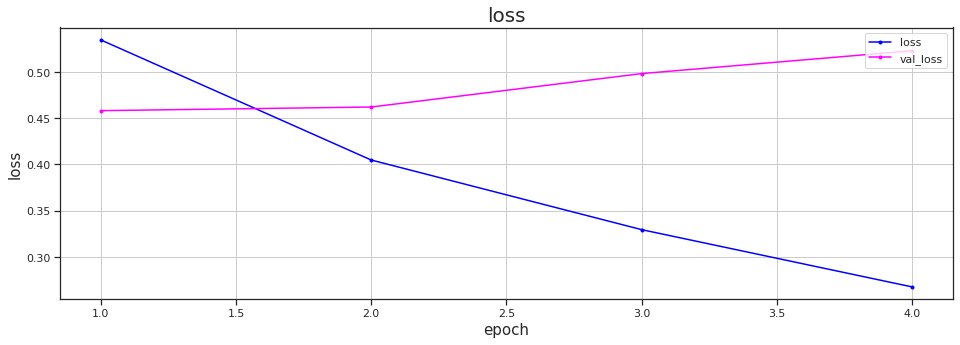

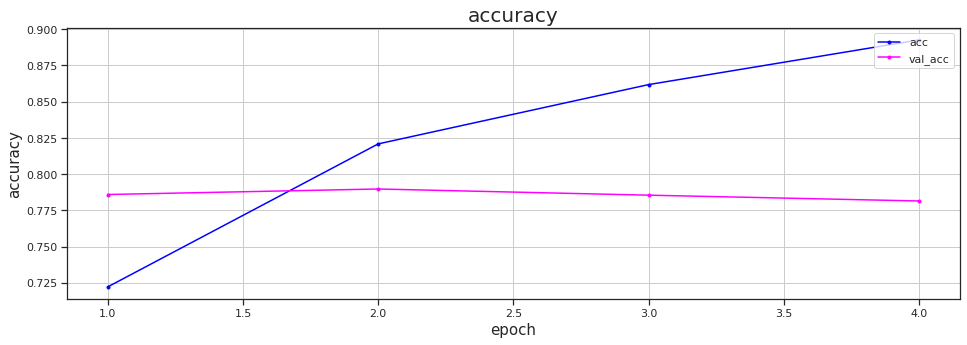

In [79]:
load_and_evaluate_model(modelpath, history, X_tr, y_train, X_te, y_test)

### BiLSTM 모델

In [80]:
# load_and_evaluate_model(modelpath_bi, history_bi, X_tr, y_train, X_te, y_test)

---
## 스팀 리뷰 데이터에 적용, 처리 후 파일 생성
---

In [81]:
from keras.models import load_model

model = load_model("/content/drive/MyDrive/Colab Notebooks/model/steam_review_best_model_LSTM.h5f5", custom_objects={'Attention': Attention, "LSTM": LSTM})

print("\nmaking processed data...")
pred_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data/processed_gameWReview_02.csv")
pred_data["is review positive"] = model.predict(x_pr)

try:
    drop_attribute = ["Unnamed: 0", "Unnamed: 0.1", "review"]
    pred_data.drop(drop_attribute, axis=1, inplace=True)
except:
    pass

print("making processed data complete\n")
pred_data.to_csv(steam_game_prediction_path, index=False)
print(pred_data.info(), end='\n\n')
print(pred_data.head(5))


making processed data...
making processed data complete

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1335 entries, 0 to 1334
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   appid               1335 non-null   float64
 1   title               1335 non-null   object 
 2   releaseDate         1335 non-null   object 
 3   price               1335 non-null   float64
 4   developer tier      1335 non-null   float64
 5   publisher tier      1335 non-null   float64
 6   genre               1332 non-null   object 
 7   early access        1335 non-null   float64
 8   achievement         1335 non-null   float64
 9   tag                 1335 non-null   object 
 10  languages           1335 non-null   float64
 11  steam award         1335 non-null   float64
 12  DLC                 1335 non-null   float64
 13  recent positive     524 non-null    object 
 14  all positive        1315 non-null   object 
 1

### 처리된 파일 확인

In [82]:
result = pd.read_csv(steam_game_prediction_path)
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1335 entries, 0 to 1334
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   appid               1335 non-null   float64
 1   title               1335 non-null   object 
 2   releaseDate         1335 non-null   object 
 3   price               1335 non-null   float64
 4   developer tier      1335 non-null   float64
 5   publisher tier      1335 non-null   float64
 6   genre               1332 non-null   object 
 7   early access        1335 non-null   float64
 8   achievement         1335 non-null   float64
 9   tag                 1335 non-null   object 
 10  languages           1335 non-null   float64
 11  steam award         1335 non-null   float64
 12  DLC                 1335 non-null   float64
 13  recent positive     524 non-null    object 
 14  all positive        1315 non-null   object 
 15  single or multi     1284 non-null   object 
 16  positi